# Part 2: Hands-On Engineering

This notebook demonstrates implementation using **Polars** (with Pandas equivalents in comments).

Data file: `data/fashion_sample.csv`

## Data Context

**Dataset:** `data/fashion_sample.csv`  
**Coverage:** 100 days of data for one product at one store

**Columns:**
- `date` - Date of observation
- `style` - Product style identifier
- `site` - Store/site identifier
- `sales` - Units sold
- `inventory` - Stock on hand
- `original_price` - Original/list price
- `current_price` - Current selling price
- `cost` - Product cost
- `launch_date` - Product launch date

**Data Periods:**
- **Days 1-40:** Normal sales period
- **Days 41-50:** Stockout period (inventory=0)
- **Days 70+:** Markdown period (price drops)

**Note:** Dataset contains intentional data quality issues to reflect real-world scenarios.

## Setup and Imports

In [35]:
# Import required libraries
import polars as pl
# import Pandas as pd  # Pandas equivalent

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pl.Config.set_tbl_rows(20)
# pd.set_option('display.max_rows', 20)  # Pandas

print(f"Polars version: {pl.__version__}")
print("Setup complete!")

Polars version: 1.38.0
Setup complete!


# Task 4: Analysis & Features

### Part A: Exploration

Loading the dataset using Polars and Pandas for comparison.

In [36]:
# Load the data
df = pl.read_csv("data/fashion_sample.csv")
# df = pd.read_csv("data/fashion_sample.csv")  # Pandas

print(f"Shape: {df.shape}")
df.head()

Shape: (100, 9)


date,style,site,sales,inventory,original_price,current_price,cost,launch_date
str,str,str,i64,i64,f64,f64,f64,str
"""2024-01-01""","""ATH-RUN-2024-BLK""","""STORE_001""",12,450,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-02""","""ATH-RUN-2024-BLK""","""STORE_001""",8,442,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-03""","""ATH-RUN-2024-BLK""","""STORE_001""",15,427,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-04""","""ATH-RUN-2024-BLK""","""STORE_001""",11,416,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-05""","""ATH-RUN-2024-BLK""","""STORE_001""",19,397,129.99,129.99,45.5,"""2023-12-15"""


In [37]:
# Convert date columns to proper types and extract date features
df = df.with_columns([
    pl.col("date").str.to_date().alias("date"),
    pl.col("launch_date").str.to_date().alias("launch_date")
])

# Add day_number column (Day 1, Day 2, ..., Day N)
df = df.with_columns([
    (pl.col("date").rank(method="dense") - 1 + 1).cast(pl.Int32).alias("day_number")
])
# Pandas equivalent:
# df['day_number'] = (df['date'] - df['date'].min()).dt.days + 1


# Extract 'date' feature as integers
df = df.with_columns([
    pl.col("date").dt.day().alias("date_day"),
    pl.col("date").dt.month().alias("date_month"),
    pl.col("date").dt.year().alias("date_year"),
    pl.col("date").dt.weekday().alias("date_weekday")
])

# Extract 'launch_date' feature as integers
df = df.with_columns([
    pl.col("launch_date").dt.day().alias("launch_date_day"),
    pl.col("launch_date").dt.month().alias("launch_date_month"),
    pl.col("launch_date").dt.year().alias("launch_date_year"),
    pl.col("launch_date").dt.weekday().alias("launch_date_weekday")
])

# Pandas equivalent for date features:
# df['date'] = pd.to_datetime(df['date'])
# df['launch_date'] = pd.to_datetime(df['launch_date'])
# df['date_day'] = df['date'].dt.day
# df['date_month'] = df['date'].dt.month
# df['date_year'] = df['date'].dt.year
# df['date_weekday'] = df['date'].dt.weekday

print("Date columns converted, day_number added, and components extracted:")

print(f"Date range: Day 1 ({df['date'].min()}) to Day {df['day_number'].max()} ({df['date'].max()})")

df.select(["date", "day_number", "date_day", "date_month", "date_year", "date_weekday", "launch_date", "launch_date_day", "launch_date_month", "launch_date_year", "launch_date_weekday"]).head(10)

Date columns converted, day_number added, and components extracted:
Date range: Day 1 (2024-01-01) to Day 100 (2024-04-09)


date,day_number,date_day,date_month,date_year,date_weekday,launch_date,launch_date_day,launch_date_month,launch_date_year,launch_date_weekday
date,i32,i8,i8,i32,i8,date,i8,i8,i32,i8
2024-01-01,1,1,1,2024,1,2023-12-15,15,12,2023,5
2024-01-02,2,2,1,2024,2,2023-12-15,15,12,2023,5
2024-01-03,3,3,1,2024,3,2023-12-15,15,12,2023,5
2024-01-04,4,4,1,2024,4,2023-12-15,15,12,2023,5
2024-01-05,5,5,1,2024,5,2023-12-15,15,12,2023,5
2024-01-06,6,6,1,2024,6,2023-12-15,15,12,2023,5
2024-01-07,7,7,1,2024,7,2023-12-15,15,12,2023,5
2024-01-08,8,8,1,2024,1,2023-12-15,15,12,2023,5
2024-01-09,9,9,1,2024,2,2023-12-15,15,12,2023,5


In [38]:
df.describe()

statistic,date,style,site,sales,inventory,original_price,current_price,cost,launch_date,day_number,date_day,date_month,date_year,date_weekday,launch_date_day,launch_date_month,launch_date_year,launch_date_weekday
str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""100""","""100""","""100""",99.0,100.0,100.0,100.0,100.0,"""100""",100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
"""null_count""","""0""","""0""","""0""",1.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-02-19 12:00:00""",null,null,9.111111,79.19,129.99,111.89,45.5,"""2023-12-15 00:00:00""",50.5,14.72,2.18,2024.0,3.95,15.0,12.0,2023.0,5.0
"""std""",null,null,null,9.381798,123.304067,0.0,29.360009,0.0,null,29.011492,8.991668,0.978352,0.0,2.021975,0.0,0.0,0.0,0.0
"""min""","""2024-01-01""","""ATH-RUN-2024-BLK""","""STORE_001""",0.0,0.0,129.99,49.99,45.5,"""2023-12-15""",1.0,1.0,1.0,2024.0,1.0,15.0,12.0,2023.0,5.0
"""25%""","""2024-01-26""",null,null,0.0,0.0,129.99,99.99,45.5,"""2023-12-15""",26.0,7.0,1.0,2024.0,2.0,15.0,12.0,2023.0,5.0
"""50%""","""2024-02-20""",null,null,8.0,15.0,129.99,129.99,45.5,"""2023-12-15""",51.0,14.0,2.0,2024.0,4.0,15.0,12.0,2023.0,5.0
"""75%""","""2024-03-15""",null,null,15.0,104.0,129.99,129.99,45.5,"""2023-12-15""",75.0,22.0,3.0,2024.0,6.0,15.0,12.0,2023.0,5.0
"""max""","""2024-04-09""","""ATH-RUN-2024-BLK""","""STORE_001""",42.0,450.0,129.99,129.99,45.5,"""2023-12-15""",100.0,31.0,4.0,2024.0,7.0,15.0,12.0,2023.0,5.0


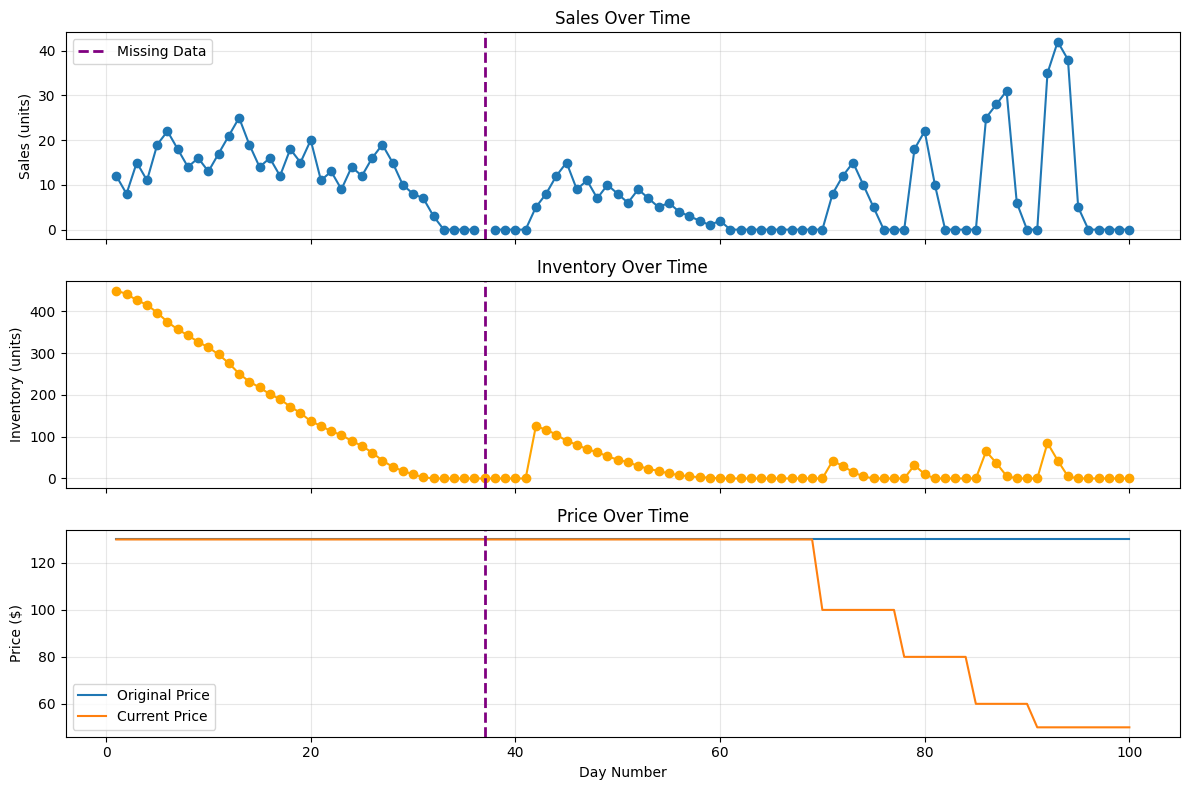

In [39]:
# Plot sales and inventory over time using day_number on x-axis
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Convert to Pandas for plotting (Polars -> Pandas conversion) (Polars doesn't provide direct matplotlib plotting helpers)
df_pd = df.to_pandas()

# Find the day with null sales value
null_sales_day = df_pd[df_pd['sales'].isna()]['day_number'].values
if len(null_sales_day) > 0:
    null_day = null_sales_day[0]
    print(f"Warning: Found null sales value on Day {null_day}")
else:
    null_day = None

# Sales
axes[0].plot(df_pd['day_number'], df_pd['sales'], marker='o', linewidth=1.5)
axes[0].set_ylabel('Sales (units)')
axes[0].set_title('Sales Over Time')
axes[0].grid(alpha=0.3)
if null_day is not None:
    axes[0].axvline(x=null_day, color='purple', linestyle='--', linewidth=2, label='Missing Data')
axes[0].legend()

# Inventory
axes[1].plot(df_pd['day_number'], df_pd['inventory'], marker='o', linewidth=1.5, color='orange')
axes[1].set_ylabel('Inventory (units)')
axes[1].set_title('Inventory Over Time')
axes[1].grid(alpha=0.3)
if null_day is not None:
    axes[1].axvline(x=null_day, color='purple', linestyle='--', linewidth=2)

# Price
axes[2].plot(df_pd['day_number'], df_pd['original_price'], label='Original Price', linewidth=1.5)
axes[2].plot(df_pd['day_number'], df_pd['current_price'], label='Current Price', linewidth=1.5)
axes[2].set_ylabel('Price ($)')
axes[2].set_xlabel('Day Number')
axes[2].set_title('Price Over Time')
axes[2].legend()
axes[2].grid(alpha=0.3)
if null_day is not None:
    axes[2].axvline(x=null_day, color='purple', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

We can tell there is a data quality issue with one day (day 37) missing a sales data point. Thankfully, the inventory on day 37 was zero, so if we must create synthetic sales for that day we can assume it is also zero. My confidence also stems from looking at the day before and after. It can affect forecast accuracy since a null sales value doesn't mean demand was nonexistent (0). Even a zero sale doesn't imply low demand. In this case, it is an effect of no inventory left to produce a sale - a classic demand censoring problem that can arise in the forecast. We can also observe a clear spike in sales due to price discounts, but when the item quickly sold out thanks to the discount the inventories dropped and were not replenished in time. There is correlation here: price down, sales up, inventory cleared to zero. The stockout period begins when inventory falls to zero until we replenish. Obviously, sales collapse during the stockout period. The trend of sales has structure that is consistent with inventory in the beginning, but its structure breaks when stockout periods occur and when there is sharp replenishing. Sales structure also breaks when markdowns happen. For modeling, we can treat stockout days as a special regime and include flags for them. The null day can be synthetically filled or ignored with flags. We can model with inclusion or exclusion of stockout periods or pattern-breaking periods in sales. Flags and inclusions can be pre- and post-stockout and pre- and post-discount periods. With this we can capture demand response to discounts. Flags and no null values positively affect forecasting. Structure breaks and demand censoring negatively affect the model. Regarding correlation: if too many features are correlated and included in the model it can negatively affect performance. We should keep one of the correlated features or use combinations.

First stockout day (inventory = 0): Day 32
Last stockout day: Day 100

Zooming into stockout period: Days 30-104
Stockout period: Days 32-100
Data points: 71


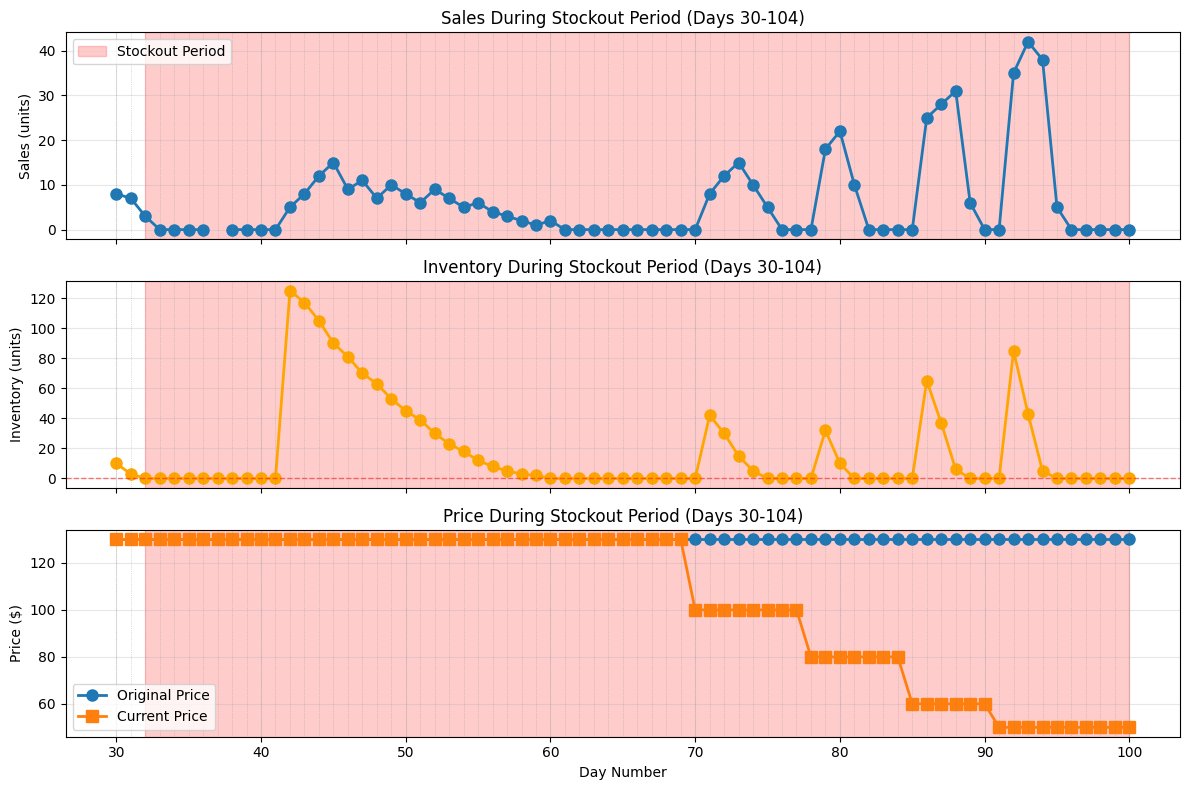

In [40]:
# Focus on stockout period: Find when inventory first reaches 0, then show ±buffer days

# Find the first day when inventory reaches 0
first_stockout_day = df_pd[df_pd['inventory'] == 0]['day_number'].min()
print(f"First stockout day (inventory = 0): Day {first_stockout_day}")

# Find the last day of stockout
last_stockout_day = df_pd[df_pd['inventory'] == 0]['day_number'].max()
print(f"Last stockout day: Day {last_stockout_day}")

# Set buffer: 2 days before first stockout, 4 days after last stockout
buffer_before = 2
buffer_after = 4

filter_start = first_stockout_day - buffer_before
filter_end = last_stockout_day + buffer_after

df_stockout = df_pd[(df_pd['day_number'] >= filter_start) & (df_pd['day_number'] <= filter_end)]

print(f"\nZooming into stockout period: Days {filter_start}-{filter_end}")
print(f"Stockout period: Days {first_stockout_day}-{last_stockout_day}")
print(f"Data points: {len(df_stockout)}")

# Plot zoomed-in view of stockout period
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Sales
axes[0].plot(df_stockout['day_number'], df_stockout['sales'], marker='o', linewidth=2, markersize=8)
axes[0].set_ylabel('Sales (units)')
axes[0].set_title(f'Sales During Stockout Period (Days {filter_start}-{filter_end})')
axes[0].grid(alpha=0.3)
axes[0].axvspan(first_stockout_day, last_stockout_day, alpha=0.2, color='red', label='Stockout Period')

# Add vertical dotted lines for each day
for day in df_stockout['day_number'].unique():
    axes[0].axvline(x=day, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

axes[0].legend()

# Inventory
axes[1].plot(df_stockout['day_number'], df_stockout['inventory'], marker='o', linewidth=2, markersize=8, color='orange')
axes[1].set_ylabel('Inventory (units)')
axes[1].set_title(f'Inventory During Stockout Period (Days {filter_start}-{filter_end})')
axes[1].grid(alpha=0.3)
axes[1].axvspan(first_stockout_day, last_stockout_day, alpha=0.2, color='red')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Add vertical dotted lines for each day
for day in df_stockout['day_number'].unique():
    axes[1].axvline(x=day, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

# Price
axes[2].plot(df_stockout['day_number'], df_stockout['original_price'], label='Original Price', linewidth=2, markersize=8, marker='o')
axes[2].plot(df_stockout['day_number'], df_stockout['current_price'], label='Current Price', linewidth=2, markersize=8, marker='s')
axes[2].set_ylabel('Price ($)')
axes[2].set_xlabel('Day Number')
axes[2].set_title(f'Price During Stockout Period (Days {filter_start}-{filter_end})')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].axvspan(first_stockout_day, last_stockout_day, alpha=0.2, color='red')

# Add vertical dotted lines for each day
for day in df_stockout['day_number'].unique():
    axes[2].axvline(x=day, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

Here just making sure that we don't have sales when the day has zero inventory. This would be a data quality issue and illogical.

In [41]:
# Check for illogical patterns (sales when inventory = 0)

# Using Polars to find different scenarios
print("=== Data Quality Checks ===\n")

# Scenario 1: Days where sales = 0 AND inventory = 0
# no inventory, no sales OK
scenario_1 = df.filter(
    (pl.col("sales") == 0) & (pl.col("inventory") == 0) # Pandas equivalent: (df['sales'] == 0) & (df['inventory'] == 0
)
print(f"Scenario 1: Sales = 0 AND Inventory = 0")
print(f"Count: {len(scenario_1)} days")
print(f"This is EXPECTED behavior (no stock = no sales)\n")

# Scenario 2: Days where sales > 0 AND inventory = 0
# can't sell what you don't have
scenario_2 = df.filter(
    (pl.col("sales") > 0) & (pl.col("inventory") == 0)  # Pandas equivalent: (df['sales'] > 0) & (df['inventory'] == 0
)
print(f"Scenario 2: Sales > 0 AND Inventory = 0")
print(f"Count: {len(scenario_2)} days")
if len(scenario_2) > 0:
    print("ILLOGICAL")
    print("Days with this issue:")
    print(scenario_2.select(["day_number", "date", "sales", "inventory"]))
else:
    print(f"✓ No illogical sales found\n")

# Additional check: Days with sales but low inventory (edge case)
print(f"\nScenario 3: Sales > 0 with inventory 1-5 (edge case)")
scenario_3 = df.filter(
    (pl.col("sales") > 0) & (pl.col("inventory") > 0) & (pl.col("inventory") <= 5)  # Pandas equivalent: (df['sales'] > 0) & (df['inventory'] > 0) & (df['inventory'] <= 5
)
print(f"Count: {len(scenario_3)} days")
if len(scenario_3) > 0:
    print(scenario_3.select(["day_number", "date", "sales", "inventory"]).head(10))

=== Data Quality Checks ===

Scenario 1: Sales = 0 AND Inventory = 0
Count: 32 days
This is EXPECTED behavior (no stock = no sales)

Scenario 2: Sales > 0 AND Inventory = 0
Count: 6 days
ILLOGICAL
Days with this issue:
shape: (6, 4)
┌────────────┬────────────┬───────┬───────────┐
│ day_number ┆ date       ┆ sales ┆ inventory │
│ ---        ┆ ---        ┆ ---   ┆ ---       │
│ i32        ┆ date       ┆ i64   ┆ i64       │
╞════════════╪════════════╪═══════╪═══════════╡
│ 32         ┆ 2024-02-01 ┆ 3     ┆ 0         │
│ 60         ┆ 2024-02-29 ┆ 2     ┆ 0         │
│ 75         ┆ 2024-03-15 ┆ 5     ┆ 0         │
│ 81         ┆ 2024-03-21 ┆ 10    ┆ 0         │
│ 89         ┆ 2024-03-29 ┆ 6     ┆ 0         │
│ 95         ┆ 2024-04-04 ┆ 5     ┆ 0         │
└────────────┴────────────┴───────┴───────────┘

Scenario 3: Sales > 0 with inventory 1-5 (edge case)
Count: 6 days
shape: (6, 4)
┌────────────┬────────────┬───────┬───────────┐
│ day_number ┆ date       ┆ sales ┆ inventory │
│ ---        

The illogical datapoints for sales just need to be clarified as to when sales numbers were captured. I would suggest capturing sales at the end of the previous day and marking the following day with zero inventory as a stockout period. This way we can have a more accurate picture of the demand that was censored by the stockout. It is confusing that on the same day inventory reached 0 there were sales; this is a data quality issue that needs clarification. If sales are captured at the end of the day, then the day inventory reaches zero should be marked as a stockout day with zero sales. This would give us a more accurate picture of the demand that was censored by the stockout. Then there are edge cases where we had too many sales for the inventory available. We can't sell product that doesn't exist. Maybe demand was high but we couldn't fulfill it. These overestimates create bias for the model, same with null days. The sample is not long enough and most of the time-series lives in a regime that the model will be trained on and have bias for. We can add flags for regimes such as stockouts and price discounts.

### Part B: Feature Engineering

### Stockout Detection

In [42]:
# Create stockout flag: inventory=0 but had recent sales (last 7 days)
# Assumption - 7 day window - recent sales - today and last 6 inclusive days
recent_sales_window = 7
df = df.with_columns([
    ((pl.col("inventory") == 0) & (pl.col("sales").shift(1).rolling_sum(recent_sales_window) > 0)).alias("is_stockout")
])
# Pandas: df['is_stockout'] = (df['inventory'] == 0) & (df['sales'].shift(1).rolling(7).sum() > 0)
# Moving sum

df.select(["day_number", "sales", "inventory", "is_stockout"]).tail(20)

day_number,sales,inventory,is_stockout
i32,i64,i64,bool
81,10,0,true
82,0,0,true
83,0,0,true
84,0,0,true
85,0,0,true
86,25,65,false
87,28,37,false
88,31,6,false
89,6,0,true


In [43]:
df.head(5)

date,style,site,sales,inventory,original_price,current_price,cost,launch_date,day_number,date_day,date_month,date_year,date_weekday,launch_date_day,launch_date_month,launch_date_year,launch_date_weekday,is_stockout
date,str,str,i64,i64,f64,f64,f64,date,i32,i8,i8,i32,i8,i8,i8,i32,i8,bool
2024-01-01,"""ATH-RUN-2024-BLK""","""STORE_001""",12,450,129.99,129.99,45.5,2023-12-15,1,1,1,2024,1,15,12,2023,5,false
2024-01-02,"""ATH-RUN-2024-BLK""","""STORE_001""",8,442,129.99,129.99,45.5,2023-12-15,2,2,1,2024,2,15,12,2023,5,false
2024-01-03,"""ATH-RUN-2024-BLK""","""STORE_001""",15,427,129.99,129.99,45.5,2023-12-15,3,3,1,2024,3,15,12,2023,5,false
2024-01-04,"""ATH-RUN-2024-BLK""","""STORE_001""",11,416,129.99,129.99,45.5,2023-12-15,4,4,1,2024,4,15,12,2023,5,false
2024-01-05,"""ATH-RUN-2024-BLK""","""STORE_001""",19,397,129.99,129.99,45.5,2023-12-15,5,5,1,2024,5,15,12,2023,5,false


### Product Lifecycle

In [44]:
# Calculate weeks since launch (week resets on launch weekday, if launch=Friday, new week starts every Friday aka Dec 15)
# Note: Polars weekday() returns 1=Monday, 7=Sunday
# Week increments when current weekday matches launch weekday
df = df.with_columns([
    ((pl.col("date") - pl.col("launch_date")).dt.total_days() // 7).alias("weeks_since_launch")
])
# Pandas: df['weeks_since_launch'] = (df['date'] - df['launch_date']).dt.days // 7

print(df.select(["day_number", "date", "date_weekday", "launch_date", "launch_date_weekday", "weeks_since_launch"]).head(20))

# when reaching the 5th weekday Friday we increment the week number, so if launch was on a Friday, then every Friday is a new week (week 0 = launch day to next Thursday, week 1 starts on next Friday)
print("Note: Week number increments when current weekday matches launch weekday, so if launch was on a Friday, then every Friday is a new week (week 0 = launch day to next Thursday, week 1 starts on next Friday)")

shape: (20, 6)
┌────────────┬────────────┬──────────────┬─────────────┬─────────────────────┬────────────────────┐
│ day_number ┆ date       ┆ date_weekday ┆ launch_date ┆ launch_date_weekday ┆ weeks_since_launch │
│ ---        ┆ ---        ┆ ---          ┆ ---         ┆ ---                 ┆ ---                │
│ i32        ┆ date       ┆ i8           ┆ date        ┆ i8                  ┆ i64                │
╞════════════╪════════════╪══════════════╪═════════════╪═════════════════════╪════════════════════╡
│ 1          ┆ 2024-01-01 ┆ 1            ┆ 2023-12-15  ┆ 5                   ┆ 2                  │
│ 2          ┆ 2024-01-02 ┆ 2            ┆ 2023-12-15  ┆ 5                   ┆ 2                  │
│ 3          ┆ 2024-01-03 ┆ 3            ┆ 2023-12-15  ┆ 5                   ┆ 2                  │
│ 4          ┆ 2024-01-04 ┆ 4            ┆ 2023-12-15  ┆ 5                   ┆ 2                  │
│ 5          ┆ 2024-01-05 ┆ 5            ┆ 2023-12-15  ┆ 5                   ┆ 3     

In [45]:
# Classify as: new/growth/mature/clearance based on weeks_since_launch
df.select(pl.col("weeks_since_launch")).describe()

statistic,weeks_since_launch
str,f64
"""count""",100.0
"""null_count""",0.0
"""mean""",9.07
"""std""",4.161524
"""min""",2.0
"""25%""",6.0
"""50%""",9.0
"""75%""",13.0
"""max""",16.0


In [46]:
# Classify as: new/growth/mature/clearance based on weeks_since_launch 
# Assumption: 4 even stages (business requirements can change) - strict business rule
# Assumption: clearance stage doesn't mean discount Y/N
max_weeks = df.select(pl.col("weeks_since_launch").max()).item()
stage_threshold = max_weeks / 4

df = df.with_columns([
    pl.when(pl.col("weeks_since_launch") <= stage_threshold)
        .then(pl.lit("New"))
    .when(pl.col("weeks_since_launch") <= stage_threshold * 2)
        .then(pl.lit("Growth"))
    .when(pl.col("weeks_since_launch") <= stage_threshold * 3)
        .then(pl.lit("Mature"))
    .otherwise(pl.lit("Clearance"))
    .alias("lifecycle_stage")
])
# Pandas: 
# max_weeks = df['weeks_since_launch'].max()
# stage_threshold = max_weeks / 4
# df['lifecycle_stage'] = pd.cut(df['weeks_since_launch'], bins=[0, stage_threshold, stage_threshold*2, stage_threshold*3, max_weeks], labels=['New', 'Growth', 'Mature', 'Clearance'])

print(f"Max weeks: {max_weeks}, Stage threshold: {stage_threshold}")
df.select(["day_number", "weeks_since_launch", "lifecycle_stage"]).describe()

Max weeks: 16, Stage threshold: 4.0


statistic,day_number,weeks_since_launch,lifecycle_stage
str,f64,f64,str
"""count""",100.0,100.0,"""100"""
"""null_count""",0.0,0.0,"""0"""
"""mean""",50.5,9.07,null
"""std""",29.011492,4.161524,null
"""min""",1.0,2.0,"""Clearance"""
"""25%""",26.0,6.0,null
"""50%""",51.0,9.0,null
"""75%""",75.0,13.0,null
"""max""",100.0,16.0,"""New"""


In [47]:
# Select every 5th row (indices 0, 5, 10, 15, ...) for validation
df_every_5th = df.filter(pl.arange(0, pl.len()).cast(pl.Int32) % 5 == 0)
# Pandas equivalent: df.iloc[::5]

print(f"Original rows: {len(df)}, Sampled rows: {len(df_every_5th)}")
df_every_5th.select(["day_number", "weeks_since_launch", "lifecycle_stage"])

Original rows: 100, Sampled rows: 20


day_number,weeks_since_launch,lifecycle_stage
i32,i64,str
1,2,"""New"""
6,3,"""New"""
11,3,"""New"""
16,4,"""New"""
21,5,"""Growth"""
26,6,"""Growth"""
31,6,"""Growth"""
36,7,"""Growth"""
41,8,"""Growth"""


### Sales Momentum

In [48]:
# Sales trend: Compare recent (7-day) vs longer (28-day) trend

# Handle null values before rolling calculations
df = df.with_columns([
    pl.col("sales").fill_null(0).alias("sales_filled")
])

df = df.with_columns([
    pl.col("sales_filled").rolling_mean(window_size=7, min_samples=1).alias("sales_trend_7d"),
    pl.col("sales_filled").rolling_mean(window_size=28, min_samples=1).alias("sales_trend_28d")
])

# Compare trends: positive if recent trend > longer trend (momentum up) (similar to MACD concept)
df = df.with_columns([
    (pl.col("sales_trend_7d") - pl.col("sales_trend_28d")).alias("sales_momentum")
])
# Pandas equivalent:
# df['sales_filled'] = df['sales'].fillna(0)
# df['sales_trend_7d'] = df['sales_filled'].rolling(7, min_periods=1).mean()
# df['sales_trend_28d'] = df['sales_filled'].rolling(28, min_periods=1).mean()
# df['sales_momentum'] = df['sales_trend_7d'] - df['sales_trend_28d']

print("Sales momentum (positive = accelerating, negative = decelerating):")
df.select(["day_number", "sales", "sales_trend_7d", "sales_trend_28d", "sales_momentum"]).tail(60)

Sales momentum (positive = accelerating, negative = decelerating):


day_number,sales,sales_trend_7d,sales_trend_28d,sales_momentum
i32,i64,f64,f64,f64
41,0,0.0,8.964286,-8.964286
42,5,0.714286,8.464286,-7.75
43,8,1.857143,8.25,-6.392857
44,12,3.571429,8.107143,-4.535714
45,15,5.714286,8.214286,-2.5
46,9,7.0,7.892857,-0.892857
47,11,8.571429,7.75,0.821429
48,7,9.571429,7.285714,2.285714
49,10,10.285714,7.25,3.035714


In [49]:
df.select(["day_number", "sales", "sales_trend_7d", "sales_trend_28d", "sales_momentum"]).head(30)

day_number,sales,sales_trend_7d,sales_trend_28d,sales_momentum
i32,i64,f64,f64,f64
1,12,12.0,12.0,0.0
2,8,10.0,10.0,0.0
3,15,11.666667,11.666667,0.0
4,11,11.5,11.5,0.0
5,19,13.0,13.0,0.0
6,22,14.5,14.5,0.0
7,18,15.0,15.0,0.0
8,14,15.285714,14.875,0.410714
9,16,16.428571,15.0,1.428571


In [50]:
# Sales trend within lifecycle stage: Compare recent vs longer trend per stage

# Group by lifecycle_stage and calculate rolling means (using filled sales)
df = df.with_columns([
    pl.col("sales_filled").rolling_mean(window_size=7, min_samples=1).over("lifecycle_stage").alias("sales_stage_trend_7d"),
    pl.col("sales_filled").rolling_mean(window_size=28, min_samples=1).over("lifecycle_stage").alias("sales_stage_trend_28d")
])

df = df.with_columns([
    (pl.col("sales_stage_trend_7d") - pl.col("sales_stage_trend_28d")).alias("sales_stage_momentum")
])
# Pandas equivalent:
# df['sales_stage_trend_7d'] = df.groupby('lifecycle_stage')['sales_filled'].transform(lambda x: x.rolling(7, min_periods=1).mean())
# df['sales_stage_trend_28d'] = df.groupby('lifecycle_stage')['sales_filled'].transform(lambda x: x.rolling(28, min_periods=1).mean())
# df['sales_stage_momentum'] = df['sales_stage_trend_7d'] - df['sales_stage_trend_28d']

print("Sales momentum within lifecycle stage:")
df_every_5th = df.filter(pl.arange(0, pl.len()).cast(pl.Int32) % 5 == 0)
df_every_5th.select(["day_number", "lifecycle_stage", "sales", "sales_stage_trend_7d", "sales_stage_trend_28d", "sales_stage_momentum"])

Sales momentum within lifecycle stage:


day_number,lifecycle_stage,sales,sales_stage_trend_7d,sales_stage_trend_28d,sales_stage_momentum
i32,str,i64,f64,f64,f64
1,"""New""",12,12.0,12.0,0.0
6,"""New""",22,14.5,14.5,0.0
11,"""New""",17,17.0,15.0,2.0
16,"""New""",16,17.857143,16.25,1.607143
21,"""Growth""",11,15.333333,15.333333,0.0
26,"""Growth""",16,13.571429,13.75,-0.178571
31,"""Growth""",7,12.428571,13.0,-0.571429
36,"""Growth""",0,2.571429,9.555556,-6.984127
41,"""Growth""",0,0.0,7.478261,-7.478261


In [51]:
# Inventory trend: Compare recent (7-day) vs longer (28-day) trend

df = df.with_columns([
    pl.col("inventory").rolling_mean(window_size=7, min_samples=1).alias("inventory_trend_7d"),
    pl.col("inventory").rolling_mean(window_size=28, min_samples=1).alias("inventory_trend_28d")
])

df = df.with_columns([
    (pl.col("inventory_trend_7d") - pl.col("inventory_trend_28d")).alias("inventory_momentum")
])
# Pandas equivalent:
# df['inventory_trend_7d'] = df['inventory'].rolling(7, min_periods=1).mean()
# df['inventory_trend_28d'] = df['inventory'].rolling(28, min_periods=1).mean()
# df['inventory_momentum'] = df['inventory_trend_7d'] - df['inventory_trend_28d']

print("Inventory momentum (positive = building up, negative = depleting):")
df.select(["day_number", "inventory", "inventory_trend_7d", "inventory_trend_28d", "inventory_momentum"]).tail(10)

Inventory momentum (positive = building up, negative = depleting):


day_number,inventory,inventory_trend_7d,inventory_trend_28d,inventory_momentum
i32,i64,f64,f64,f64
91,0,15.428571,8.642857,6.785714
92,85,27.571429,11.678571,15.892857
93,43,24.428571,13.214286,11.214286
94,5,19.857143,13.392857,6.464286
95,0,19.0,13.392857,5.607143
96,0,19.0,13.392857,5.607143
97,0,19.0,13.392857,5.607143
98,0,19.0,13.392857,5.607143
99,0,6.857143,11.892857,-5.035714


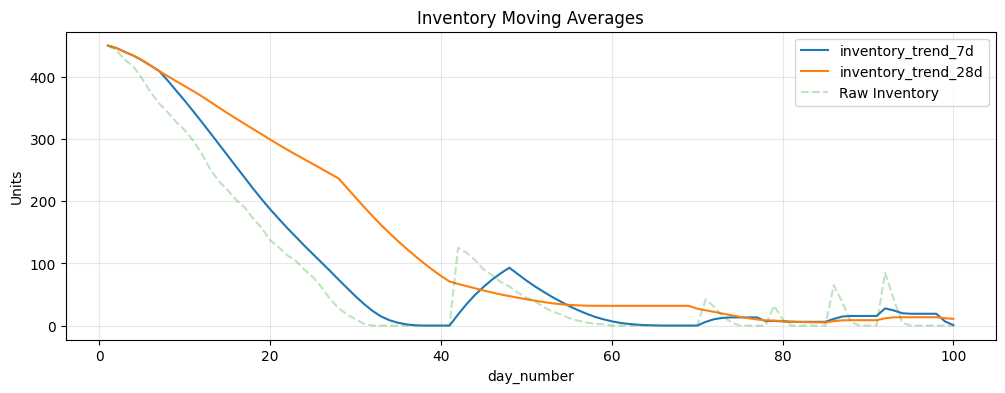

In [52]:
# Plot inventory moving averages with raw inventory overlay
ax = df.to_pandas().plot(x='day_number', y=['inventory_trend_7d', 'inventory_trend_28d'], figsize=(12, 4), title='Inventory Moving Averages')
df.to_pandas().plot(x='day_number', y='inventory', ax=ax, style='--', alpha=0.3, label='Raw Inventory')
plt.ylabel('Units')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### One-hot encode the stages for better model interpretability. It is a regression for numerical demand prediction, so having categorical variables as one-hot encoded helps the model understand the different stages.

In [53]:
# One-hot encode lifecycle_stage
df = df.to_dummies(columns=["lifecycle_stage"], separator="_")
# Pandas equivalent: df = pd.get_dummies(df, columns=['lifecycle_stage'], prefix='lifecycle_stage')

df_every_5th = df.filter(pl.arange(0, pl.len()).cast(pl.Int32) % 5 == 0)    # Pandas equivalent: df.iloc[::5]
print("One-hot encoded lifecycle_stage:")
df_every_5th.select([col for col in df.columns if col.startswith("lifecycle_stage")])

One-hot encoded lifecycle_stage:


lifecycle_stage_Clearance,lifecycle_stage_Growth,lifecycle_stage_Mature,lifecycle_stage_New
u8,u8,u8,u8
0,0,0,1
0,0,0,1
0,0,0,1
0,0,0,1
0,1,0,0
0,1,0,0
0,1,0,0
0,1,0,0
0,1,0,0


### Part C: Product Qualification

In [54]:
# Product Qualification Method
def qualify_product(dataframe, min_days=60, min_sales_total=10, max_negative_margin_days=7):
    """
    Qualify if product has sufficient data for forecasting.
    
    Args:
        dataframe: Polars DataFrame
        min_days: Minimum number of days required
        min_sales_total: Minimum total sales required
        max_negative_margin_days: Maximum consecutive days with negative/low margin allowed
    
    Returns:
        dict with qualification results
    """
    # STATS here
    total_days = dataframe.select(pl.col("day_number").max()).item()
    total_sales = dataframe.select(pl.col("sales_filled").sum()).item()
    stockout_days = dataframe.select(pl.col("is_stockout").sum()).item()
    
    # [PROFITS] Check profit margin: current_price - cost
    # Calculate margin and identify low/negative margin days
    df_margin = dataframe.with_columns([
        (pl.col("current_price") - pl.col("cost")).alias("margin"),
        ((pl.col("current_price") - pl.col("cost")) <= 0).alias("negative_margin")
    ])
    # Find maximum consecutive negative margin days
    # Group consecutive True values and count them
    df_margin = df_margin.with_columns([
        (pl.col("negative_margin").cast(pl.Int32) * 
         (pl.col("negative_margin") != pl.col("negative_margin").shift(1)).cum_sum()).alias("margin_group")
    ])
    max_consecutive_negative = df_margin.filter(pl.col("negative_margin")).group_by("margin_group").agg(
        pl.len().alias("consecutive_count")
    ).select(pl.col("consecutive_count").max()).item()
    
    if max_consecutive_negative is None:
        max_consecutive_negative = 0
    
    has_healthy_margins = max_consecutive_negative <= max_negative_margin_days  # Decision time
    
    # Pandas equivalent:
    # df['margin'] = df['current_price'] - df['cost']
    # df['negative_margin'] = df['margin'] <= 0
    # df['margin_group'] = (df['negative_margin'] != df['negative_margin'].shift()).cumsum()
    # max_consecutive_negative = df[df['negative_margin']].groupby('margin_group').size().max() or 0
    # has_healthy_margins = max_consecutive_negative <= max_negative_margin_days
    
    # MORE STATS
    #check for null values rate and can we fill with median or mean that is reasonable or use back and forward fill [DATA QUALITY]
    #check to must have recent sales in the last 2 weeks or for new product recent sales in the next 5 days of launch to consider successful launch [SALES RECENCY]
    #check the variance to how many times inventory is more than 0 and at 0 consecutively. if there are more than half of the days that inventory is 0 then boolean should be false and pivot the qualified variable to false [INVENTORY AGE]

    
    qualified = (total_days >= min_days) and (total_sales >= min_sales_total) and has_healthy_margins
    # add more stats to be true in this boolean to qualify (mix AND and OR combinations) -> business rules here to be decided with SME
    
    return {
        "qualified": qualified,
        "total_days": total_days,
        "total_sales": total_sales,
        "stockout_days": stockout_days,
        "stockout_rate": stockout_days / total_days if total_days > 0 else 0,
        "max_consecutive_negative_margin_days": max_consecutive_negative,
        "has_healthy_margins": has_healthy_margins
    }

In [55]:
# Qualify the product
result = qualify_product(df)
print(f"Product Qualified: {result['qualified']}")
print(f"Details: {result}")

Product Qualified: True
Details: {'qualified': True, 'total_days': 100, 'total_sales': 902, 'stockout_days': 32, 'stockout_rate': 0.32, 'max_consecutive_negative_margin_days': 0, 'has_healthy_margins': True}


# Task 5: Model Comparison

## Split

In [56]:
# Display all columns with their data types and statistics
print(f"Total columns: {len(df.columns)}\n")

print("=== Column Schema (Name and Data Type) ===")
for col_name, col_type in df.schema.items():
    print(f"{col_name:<40} {col_type}")

print("\n=== Descriptive Statistics for All Numeric Columns ===")
df.describe()

# Pandas equivalent:
# print(df.dtypes)  # for schema
# print(df.describe())  # for statistics
# or df.info() for both

Total columns: 34

=== Column Schema (Name and Data Type) ===
date                                     Date
style                                    String
site                                     String
sales                                    Int64
inventory                                Int64
original_price                           Float64
current_price                            Float64
cost                                     Float64
launch_date                              Date
day_number                               Int32
date_day                                 Int8
date_month                               Int8
date_year                                Int32
date_weekday                             Int8
launch_date_day                          Int8
launch_date_month                        Int8
launch_date_year                         Int32
launch_date_weekday                      Int8
is_stockout                              Boolean
weeks_since_launch                       In

statistic,date,style,site,sales,inventory,original_price,current_price,cost,launch_date,day_number,date_day,date_month,date_year,date_weekday,launch_date_day,launch_date_month,launch_date_year,launch_date_weekday,is_stockout,weeks_since_launch,lifecycle_stage_Clearance,lifecycle_stage_Growth,lifecycle_stage_Mature,lifecycle_stage_New,sales_filled,sales_trend_7d,sales_trend_28d,sales_momentum,sales_stage_trend_7d,sales_stage_trend_28d,sales_stage_momentum,inventory_trend_7d,inventory_trend_28d,inventory_momentum
str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""100""","""100""","""100""",99.0,100.0,100.0,100.0,100.0,"""100""",100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,96.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
"""null_count""","""0""","""0""","""0""",1.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-02-19 12:00:00""",null,null,9.111111,79.19,129.99,111.89,45.5,"""2023-12-15 00:00:00""",50.5,14.72,2.18,2024.0,3.95,15.0,12.0,2023.0,5.0,0.333333,9.07,0.26,0.28,0.28,0.18,9.02,9.360952,9.489448,-0.128496,9.131238,9.588777,-0.457539,92.419357,129.711358,-37.292001
"""std""",null,null,null,9.381798,123.304067,0.0,29.360009,0.0,null,29.011492,8.991668,0.978352,0.0,2.021975,0.0,0.0,0.0,0.0,null,4.161524,0.440844,0.451261,0.451261,0.386123,9.378656,5.958673,4.527424,4.463971,6.093528,4.095303,3.3256,134.976663,146.521761,56.710865
"""min""","""2024-01-01""","""ATH-RUN-2024-BLK""","""STORE_001""",0.0,0.0,129.99,49.99,45.5,"""2023-12-15""",1.0,1.0,1.0,2024.0,1.0,15.0,12.0,2023.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,3.392857,-10.785714,0.0,1.25,-8.190476,0.0,4.964286,-162.571429
"""25%""","""2024-01-26""",null,null,0.0,0.0,129.99,99.99,45.5,"""2023-12-15""",26.0,7.0,1.0,2024.0,2.0,15.0,12.0,2023.0,5.0,null,6.0,0.0,0.0,0.0,0.0,0.0,5.142857,4.642857,-2.5,4.0,6.666667,-2.137566,6.857143,14.035714,-70.821429
"""50%""","""2024-02-20""",null,null,8.0,15.0,129.99,129.99,45.5,"""2023-12-15""",51.0,14.0,2.0,2024.0,4.0,15.0,12.0,2023.0,5.0,null,9.0,0.0,0.0,0.0,0.0,8.0,8.857143,8.464286,0.410714,8.857143,9.0625,0.0,19.285714,42.321429,-11.642857
"""75%""","""2024-03-15""",null,null,15.0,104.0,129.99,129.99,45.5,"""2023-12-15""",75.0,22.0,3.0,2024.0,6.0,15.0,12.0,2023.0,5.0,null,13.0,1.0,1.0,1.0,0.0,15.0,14.0,14.8,2.607143,13.666667,13.0,1.342857,101.428571,252.038462,1.035714
"""max""","""2024-04-09""","""ATH-RUN-2024-BLK""","""STORE_001""",42.0,450.0,129.99,129.99,45.5,"""2023-12-15""",100.0,31.0,4.0,2024.0,7.0,15.0,12.0,2023.0,5.0,1.0,16.0,1.0,1.0,1.0,1.0,42.0,21.714286,16.428571,10.821429,21.714286,17.5,8.714286,450.0,450.0,45.642857


In [57]:
# After some research I realize that there is leakage and we can shift by one day to create the lag features. I investigated further and found that rolling mean includes current day which is not realistic for forecasting. So we shift by 1 day to avoid leakage.
# Update sales trend calculations to shift by 1 day to avoid leakage
df = df.with_columns([
    pl.col("sales_filled").rolling_mean(window_size=28, min_samples=1).shift(1).alias("sales_trend_28d_lag1"),  # Pandas equivalent: df['sales_trend_28d_lag1'] = df['sales_filled'].rolling(28, min_periods=1).mean().shift(1)
    pl.col("sales_filled").rolling_mean(window_size=14, min_samples=1).shift(1).alias("sales_trend_14d_lag1"),
    pl.col("sales_filled").rolling_mean(window_size=7, min_samples=1).shift(1).alias("sales_trend_7d_lag1")
])

# Display all columns with their data types and statistics
print(f"Total columns: {len(df.columns)}\n")

print("=== Column Schema (Name and Data Type) ===")
for col_name, col_type in df.schema.items():
    print(f"{col_name:<40} {col_type}")

print("\n=== Descriptive Statistics for All Numeric Columns ===")
df.describe()

Total columns: 37

=== Column Schema (Name and Data Type) ===
date                                     Date
style                                    String
site                                     String
sales                                    Int64
inventory                                Int64
original_price                           Float64
current_price                            Float64
cost                                     Float64
launch_date                              Date
day_number                               Int32
date_day                                 Int8
date_month                               Int8
date_year                                Int32
date_weekday                             Int8
launch_date_day                          Int8
launch_date_month                        Int8
launch_date_year                         Int32
launch_date_weekday                      Int8
is_stockout                              Boolean
weeks_since_launch                       In

statistic,date,style,site,sales,inventory,original_price,current_price,cost,launch_date,day_number,date_day,date_month,date_year,date_weekday,launch_date_day,launch_date_month,launch_date_year,launch_date_weekday,is_stockout,weeks_since_launch,lifecycle_stage_Clearance,lifecycle_stage_Growth,lifecycle_stage_Mature,lifecycle_stage_New,sales_filled,sales_trend_7d,sales_trend_28d,sales_momentum,sales_stage_trend_7d,sales_stage_trend_28d,sales_stage_momentum,inventory_trend_7d,inventory_trend_28d,inventory_momentum,sales_trend_28d_lag1,sales_trend_14d_lag1,sales_trend_7d_lag1
str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""100""","""100""","""100""",99.0,100.0,100.0,100.0,100.0,"""100""",100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,96.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,99.0,99.0,99.0
"""null_count""","""0""","""0""","""0""",1.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
"""mean""","""2024-02-19 12:00:00""",null,null,9.111111,79.19,129.99,111.89,45.5,"""2023-12-15 00:00:00""",50.5,14.72,2.18,2024.0,3.95,15.0,12.0,2023.0,5.0,0.333333,9.07,0.26,0.28,0.28,0.18,9.02,9.360952,9.489448,-0.128496,9.131238,9.588777,-0.457539,92.419357,129.711358,-37.292001,9.480684,9.264079,9.393458
"""std""",null,null,null,9.381798,123.304067,0.0,29.360009,0.0,null,29.011492,8.991668,0.978352,0.0,2.021975,0.0,0.0,0.0,0.0,null,4.161524,0.440844,0.451261,0.451261,0.386123,9.378656,5.958673,4.527424,4.463971,6.093528,4.095303,3.3256,134.976663,146.521761,56.710865,4.549611,5.195114,5.980079
"""min""","""2024-01-01""","""ATH-RUN-2024-BLK""","""STORE_001""",0.0,0.0,129.99,49.99,45.5,"""2023-12-15""",1.0,1.0,1.0,2024.0,1.0,15.0,12.0,2023.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,3.392857,-10.785714,0.0,1.25,-8.190476,0.0,4.964286,-162.571429,3.392857,0.571429,0.0
"""25%""","""2024-01-26""",null,null,0.0,0.0,129.99,99.99,45.5,"""2023-12-15""",26.0,7.0,1.0,2024.0,2.0,15.0,12.0,2023.0,5.0,null,6.0,0.0,0.0,0.0,0.0,0.0,5.142857,4.642857,-2.5,4.0,6.666667,-2.137566,6.857143,14.035714,-70.821429,4.642857,4.785714,5.142857
"""50%""","""2024-02-20""",null,null,8.0,15.0,129.99,129.99,45.5,"""2023-12-15""",51.0,14.0,2.0,2024.0,4.0,15.0,12.0,2023.0,5.0,null,9.0,0.0,0.0,0.0,0.0,8.0,8.857143,8.464286,0.410714,8.857143,9.0625,0.0,19.285714,42.321429,-11.642857,8.25,8.357143,8.857143
"""75%""","""2024-03-15""",null,null,15.0,104.0,129.99,129.99,45.5,"""2023-12-15""",75.0,22.0,3.0,2024.0,6.0,15.0,12.0,2023.0,5.0,null,13.0,1.0,1.0,1.0,0.0,15.0,14.0,14.8,2.607143,13.666667,13.0,1.342857,101.428571,252.038462,1.035714,14.857143,14.875,14.285714
"""max""","""2024-04-09""","""ATH-RUN-2024-BLK""","""STORE_001""",42.0,450.0,129.99,129.99,45.5,"""2023-12-15""",100.0,31.0,4.0,2024.0,7.0,15.0,12.0,2023.0,5.0,1.0,16.0,1.0,1.0,1.0,1.0,42.0,21.714286,16.428571,10.821429,21.714286,17.5,8.714286,450.0,450.0,45.642857,16.428571,17.428571,21.714286


In [58]:
# Train/test split: first 80 days train, last 20 days test (time-series split)
train_df, test_df = df.filter(pl.col("day_number") <= 80), df.filter(pl.col("day_number") > 80)
print(f"Train: {len(train_df)} rows (days 1-80), Test: {len(test_df)} rows (days 81-100)")

# Pandas equivalent: train_df = df[df['day_number'] <= 80]; test_df = df[df['day_number'] > 80]

Train: 80 rows (days 1-80), Test: 20 rows (days 81-100)


## Build

## baseline

In [59]:
# Install required packages
!pip install scikit-learn

In [60]:
# Baseline: 28-day moving average (single feature 28d)


# Define feature and target
baseline_features = ["sales_trend_28d"]
target = "sales_filled" 

# Prepare train data - drop rows where the feature is null
train_baseline = train_df.drop_nulls(subset=baseline_features)   # Pandas equivalent: train_baseline = train_df.dropna(subset=baseline_features)
X_train = train_baseline.select(baseline_features).to_numpy()    # Pandas equivalent: X_train = train_baseline[baseline_features].to_numpy()
y_train = train_baseline.select(target).to_numpy().flatten()    # Pandas equivalent: y_train = train_baseline[target].to_numpy().flatten()

# Prepare test data
test_baseline = test_df.drop_nulls(subset=baseline_features)   # Pandas equivalent: test_baseline = test_df.dropna(subset=baseline_features)
X_test = test_baseline.select(baseline_features).to_numpy()    # Pandas equivalent: X_test = test_baseline[baseline_features].to_numpy()
y_test = test_baseline.select(target).to_numpy().flatten()    # Pandas equivalent: y_test = test_baseline[target].to_numpy().flatten()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print(X_train)
print(df.select("sales_trend_28d").head(10))
print(y_train)
print(df.select("sales_filled").head(10))

(80, 1) (80,) (20, 1) (20,)
[[12.        ]
 [10.        ]
 [11.66666667]
 [11.5       ]
 [13.        ]
 [14.5       ]
 [15.        ]
 [14.875     ]
 [15.        ]
 [14.8       ]
 [15.        ]
 [15.5       ]
 [16.23076923]
 [16.42857143]
 [16.26666667]
 [16.25      ]
 [16.        ]
 [16.11111111]
 [16.05263158]
 [16.25      ]
 [16.        ]
 [15.86363636]
 [15.56521739]
 [15.5       ]
 [15.36      ]
 [15.38461538]
 [15.51851852]
 [15.5       ]
 [15.42857143]
 [15.42857143]
 [15.14285714]
 [14.85714286]
 [14.17857143]
 [13.39285714]
 [12.75      ]
 [12.25      ]
 [11.67857143]
 [11.21428571]
 [10.60714286]
 [ 9.85714286]
 [ 8.96428571]
 [ 8.46428571]
 [ 8.25      ]
 [ 8.10714286]
 [ 8.21428571]
 [ 7.89285714]
 [ 7.75      ]
 [ 7.28571429]
 [ 7.25      ]
 [ 7.07142857]
 [ 6.96428571]
 [ 6.78571429]
 [ 6.60714286]
 [ 6.21428571]
 [ 5.75      ]
 [ 5.35714286]
 [ 5.10714286]
 [ 4.89285714]
 [ 4.67857143]
 [ 4.64285714]
 [ 4.64285714]
 [ 4.64285714]
 [ 4.64285714]
 [ 4.64285714]
 [ 4.6428571

In [61]:
# Baseline: 28-day moving average (single feature 28d)


print(X_test)
print(df.select("sales_trend_28d").tail(10))
print(y_test)
print(df.select("sales_filled").tail(10))

[[ 4.39285714]
 [ 4.21428571]
 [ 4.        ]
 [ 3.85714286]
 [ 3.75      ]
 [ 4.57142857]
 [ 5.53571429]
 [ 6.57142857]
 [ 6.78571429]
 [ 6.78571429]
 [ 6.78571429]
 [ 8.03571429]
 [ 9.53571429]
 [10.89285714]
 [11.07142857]
 [11.07142857]
 [11.07142857]
 [11.07142857]
 [10.78571429]
 [10.35714286]]
shape: (10, 1)
┌─────────────────┐
│ sales_trend_28d │
│ ---             │
│ f64             │
╞═════════════════╡
│ 6.785714        │
│ 8.035714        │
│ 9.535714        │
│ 10.892857       │
│ 11.071429       │
│ 11.071429       │
│ 11.071429       │
│ 11.071429       │
│ 10.785714       │
│ 10.357143       │
└─────────────────┘
[10  0  0  0  0 25 28 31  6  0  0 35 42 38  5  0  0  0  0  0]
shape: (10, 1)
┌──────────────┐
│ sales_filled │
│ ---          │
│ i64          │
╞══════════════╡
│ 0            │
│ 35           │
│ 42           │
│ 38           │
│ 5            │
│ 0            │
│ 0            │
│ 0            │
│ 0            │
│ 0            │
└──────────────┘


In [ ]:
# Baseline: Simple linear regression using 28-day moving average
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

print(f"Baseline Model: Using {baseline_features[0]} as single feature")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# Train simple linear regression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predict
y_pred_baseline = baseline_model.predict(X_test)

# Statistical metrics
# WMAPE (Weighted Mean Absolute Percentage Error): calculated manually using numpy because scikit-learn doesn't provide it
# Formula: sum(|actual - predicted|) / sum(actual) * 100
# This weights errors by actual sales volume, making it more interpretable for business metrics than MAPE
# MAPE has issues with zero or near-zero values and can be asymmetric; WMAPE handles this better
baseline_wmape = np.sum(np.abs(y_test - y_pred_baseline)) / np.sum(y_test) * 100
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print(f"\nBaseline Model Performance:")
print(f"WMAPE: {baseline_wmape:.2f}%")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"MAE: {baseline_mae:.2f}")

Baseline Model: Using sales_trend_28d as single feature
Train samples: 80, Test samples: 20

Baseline Model Performance:
WMAPE: 110.43%
RMSE: 15.79
MAE: 12.15


The only feature here is the 28 day moving average of sales. 100% indicates very poor accuracy, as expected from such a naive baseline model. The errors stem from the fact that a moving average does not capture trends, seasonality, or sudden changes in sales patterns due to stockouts or markdowns. As a result, the model fails to adapt to the dynamic nature of the sales data, thus we have significant discrepancies between predicted and actual sales values. Outliers exist due to spikes in sales when a regime occurred. We need more features. Spikes come from RMSE > MAE where some days the model is off by a large margin. We can't capture regime shifts with only one feature. This performance is not acceptable. We need more features to capture the complex sales patterns.

## 3 lag features

In [63]:
# LGBM: Using only lag features (7d, 14d, 28d with 1-day shift)
try:
    import lightgbm as lgb
except OSError as e:
    raise OSError(
        "LightGBM failed to load libomp. On macOS, install it with:\n"
        "  brew install libomp\n"
        "Then restart the kernel and rerun the cell."
    ) from e

OSError: LightGBM failed to load libomp. On macOS, install it with:
  brew install libomp
Then restart the kernel and rerun the cell.

In [ ]:
# LGBM: Using only lag features (7d, 14d, 28d with 1-day shift)


# Define features and target
lag_features = ["sales_trend_7d_lag1", "sales_trend_14d_lag1", "sales_trend_28d_lag1"]
target = "sales_filled"

# Prepare train data - drop rows where the feature is null
train_lag = train_df.drop_nulls(subset=lag_features)
X_train_lag = train_lag.select(lag_features).to_numpy()
y_train_lag = train_lag.select(target).to_numpy().flatten()

# Prepare test data
test_lag = test_df.drop_nulls(subset=lag_features)
X_test_lag = test_lag.select(lag_features).to_numpy()
y_test_lag = test_lag.select(target).to_numpy().flatten()

print(f"Lag Model: Using 3 lag features (7d, 14d, 28d)")
print(f"Train samples: {len(X_train_lag)}, Test samples: {len(X_test_lag)}")

# Train LightGBM
lgbm_lag = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, verbose=-1)
lgbm_lag.fit(X_train_lag, y_train_lag)

# Predict
y_pred_lag = lgbm_lag.predict(X_test_lag)

# Statistical metrics
lag_wmape = np.sum(np.abs(y_test_lag - y_pred_lag)) / np.sum(y_test_lag) * 100
lag_rmse = np.sqrt(mean_squared_error(y_test_lag, y_pred_lag))
lag_mae = mean_absolute_error(y_test_lag, y_pred_lag)

print(f"\nLag Model Performance:")
print(f"WMAPE: {lag_wmape:.2f}%")
print(f"RMSE: {lag_rmse:.2f}")
print(f"MAE: {lag_mae:.2f}")

OSError: LightGBM failed to load libomp. On macOS, install it with:
  brew install libomp
Then restart the kernel and rerun the cell.

In [ ]:
# OS PROBLEM: using alternative with scikit-learn and no OS dependencies (I run a MacBook now discontinued that is mobile processor)
# Gradient Boosting using scikit-learn 
from sklearn.ensemble import GradientBoostingRegressor

# Define features and target
lag_features = ["sales_trend_7d_lag1", "sales_trend_14d_lag1", "sales_trend_28d_lag1"]
target = "sales_filled"

# Prepare train data - drop rows where the feature is null
train_lag = train_df.drop_nulls(subset=lag_features)
X_train_lag = train_lag.select(lag_features).to_numpy()
y_train_lag = train_lag.select(target).to_numpy().flatten()

# Prepare test data
test_lag = test_df.drop_nulls(subset=lag_features)
X_test_lag = test_lag.select(lag_features).to_numpy()
y_test_lag = test_lag.select(target).to_numpy().flatten()

print(f"Lag Model: Using 3 lag features (7d, 14d, 28d)")
print(f"Train samples: {len(X_train_lag)}, Test samples: {len(X_test_lag)}")

# Train Gradient Boosting
# Parameters: n_estimators=100 (number of boosting stages), learning_rate=0.05 (shrinks contribution of each tree),
# max_depth=3 (limits tree depth to prevent overfitting), random_state=42 (reproducibility)
# Note: These are baseline parameters; grid search can be used to optimize later
model_lag = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model_lag.fit(X_train_lag, y_train_lag)

# Predict
y_pred_lag = model_lag.predict(X_test_lag)

# Statistical metrics
# WMAPE (Weighted Mean Absolute Percentage Error): calculated manually using numpy because scikit-learn doesn't provide it
# Formula: sum(|actual - predicted|) / sum(actual) * 100
# This weights errors by actual sales volume, making it more interpretable for business metrics than MAPE
# MAPE has issues with zero or near-zero values and can be asymmetric; WMAPE handles this better
lag_wmape = np.sum(np.abs(y_test_lag - y_pred_lag)) / np.sum(y_test_lag) * 100
lag_rmse = np.sqrt(mean_squared_error(y_test_lag, y_pred_lag))  # sklearn provides RMSE via MSE
lag_mae = mean_absolute_error(y_test_lag, y_pred_lag)  # sklearn provides MAE directly

print(f"\nLag Model Performance:")
print(f"WMAPE: {lag_wmape:.2f}%")
print(f"RMSE: {lag_rmse:.2f}")
print(f"MAE: {lag_mae:.2f}")

# Feature importances
print(f"\nFeature Importances:")
importances = model_lag.feature_importances_
for feature, importance in zip(lag_features, importances):
    print(f"{feature}: {importance:.4f}")

Lag Model: Using 3 lag features (7d, 14d, 28d)
Train samples: 79, Test samples: 20

Lag Model Performance:
WMAPE: 141.33%
RMSE: 17.71
MAE: 15.55

Feature Importances:
sales_trend_7d_lag1: 0.6894
sales_trend_14d_lag1: 0.1085
sales_trend_28d_lag1: 0.2020


The train sample is 79 because we don't account for current day due to the shift of one day for lag features. The test sample is 20 days. This model is worse than the baseline model. The likely cause I think is the lag features don't capture regime changes in stockouts or markdown and then sales spike and this is only amplified with 3 more moving averages. This has inflated targets where Y train spikes and the lag moving averages are so smooth. So the preprocessing is correct with correcting for lag and avoiding leakage. The problem is the features underfit the regime changes. The lag features are smoothed and don't capture the sudden changes in sales due to stockouts and markdowns. This causes the model to miss important patterns in the data, leading to poor performance. To improve, we need features that can capture these regime shifts better, such as flags for stockouts and markdowns, or more dynamic features that respond to sudden changes in sales patterns. Overall, the lag features alone are insufficient for modeling the complex sales dynamics present in the dataset. The model overreacts to noise and spikes and produces large errors. This is not acceptable performance. We need better features that capture regime changes. We can evaluate separately the stockout periods and that the WMAPE is influenced by these regime shifts. 

We can evaluate error per feature by using the mean absolute error (MAE) see how much error comes from the feature alone. The feature importance above says 7d lag has 68% importance. The short term momentum dominates the predictions. The longer term lags are less important. This makes sense as recent sales trends are more indicative of current demand than older trends. However, relying too heavily on short-term features can make the model sensitive to noise and outliers. A balanced feature set is ideal.

## my features

In [ ]:
# OS PROBLEM: using alternative with scikit-learn and no OS dependencies (I run a MacBook now discontinued that is mobile processor)
# Gradient Boosting using scikit-learn 
from sklearn.ensemble import GradientBoostingRegressor

# Define features and target (my features)
lag_features = [
    # Lag features - sales trends
    "sales_trend_7d_lag1", 
    "sales_trend_14d_lag1", 
    "sales_trend_28d_lag1",
    # Momentum features
    "sales_momentum",
    "sales_stage_momentum",
    # Inventory features
    "inventory",
    "inventory_trend_7d",
    "inventory_trend_28d", 
    "inventory_momentum",
    # Stockout flag
    "is_stockout",
    # Product lifecycle (one-hot encoded)
    "lifecycle_stage_New",
    "lifecycle_stage_Growth", 
    "lifecycle_stage_Mature",
    "lifecycle_stage_Clearance",
    # Time features
    "weeks_since_launch",
    "date_weekday",
    # Price features
    "current_price",
    "original_price",
    "cost"
]
target = "sales_filled"

# Prepare train data - drop rows where the feature is null
train_lag = train_df.drop_nulls(subset=lag_features)
X_train_lag = train_lag.select(lag_features).to_numpy()
y_train_lag = train_lag.select(target).to_numpy().flatten()

# Prepare test data
test_lag = test_df.drop_nulls(subset=lag_features)
X_test_lag = test_lag.select(lag_features).to_numpy()
y_test_lag = test_lag.select(target).to_numpy().flatten()

print(f"My Features Model: Using {len(lag_features)} features")
print(f"Features: {lag_features}")
print(f"Train samples: {len(X_train_lag)}, Test samples: {len(X_test_lag)}")

# Train Gradient Boosting
# Parameters: n_estimators=100 (number of boosting stages), learning_rate=0.05 (shrinks contribution of each tree),
# max_depth=3 (limits tree depth to prevent overfitting), random_state=42 (reproducibility)
# Note: These are baseline parameters; grid search can be used to optimize later
model_lag = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model_lag.fit(X_train_lag, y_train_lag)

# Predict
y_pred_lag = model_lag.predict(X_test_lag)

# Statistical metrics
# WMAPE (Weighted Mean Absolute Percentage Error): calculated manually using numpy because scikit-learn doesn't provide it
# Formula: sum(|actual - predicted|) / sum(actual) * 100
# This weights errors by actual sales volume, making it more interpretable for business metrics than MAPE
# MAPE has issues with zero or near-zero values and can be asymmetric; WMAPE handles this better
lag_wmape = np.sum(np.abs(y_test_lag - y_pred_lag)) / np.sum(y_test_lag) * 100
lag_rmse = np.sqrt(mean_squared_error(y_test_lag, y_pred_lag))  # sklearn provides RMSE via MSE
lag_mae = mean_absolute_error(y_test_lag, y_pred_lag)  # sklearn provides MAE directly

print(f"\nMy Features Model Performance:")
print(f"WMAPE: {lag_wmape:.2f}%")
print(f"RMSE: {lag_rmse:.2f}")
print(f"MAE: {lag_mae:.2f}")

# Feature importances
print(f"\nFeature Importances:")
importances = model_lag.feature_importances_
for feature, importance in zip(lag_features, importances):
    print(f"{feature}: {importance:.4f}")

My Features Model: Using 19 features
Features: ['sales_trend_7d_lag1', 'sales_trend_14d_lag1', 'sales_trend_28d_lag1', 'sales_momentum', 'sales_stage_momentum', 'inventory', 'inventory_trend_7d', 'inventory_trend_28d', 'inventory_momentum', 'is_stockout', 'lifecycle_stage_New', 'lifecycle_stage_Growth', 'lifecycle_stage_Mature', 'lifecycle_stage_Clearance', 'weeks_since_launch', 'date_weekday', 'current_price', 'original_price', 'cost']
Train samples: 75, Test samples: 20

My Features Model Performance:
WMAPE: 86.94%
RMSE: 12.11
MAE: 9.56

Feature Importances:
sales_trend_7d_lag1: 0.0156
sales_trend_14d_lag1: 0.0114
sales_trend_28d_lag1: 0.0125
sales_momentum: 0.0168
sales_stage_momentum: 0.0272
inventory: 0.6365
inventory_trend_7d: 0.0562
inventory_trend_28d: 0.1425
inventory_momentum: 0.0059
is_stockout: 0.0000
lifecycle_stage_New: 0.0000
lifecycle_stage_Growth: 0.0000
lifecycle_stage_Mature: 0.0159
lifecycle_stage_Clearance: 0.0000
weeks_since_launch: 0.0075
date_weekday: 0.0521
cur

This WMAPE is still poor for production. We need a larger sample size first of all. The features help capture regime changes better. The stockout flag and markdown flag help the model understand when sales patterns shift dramatically. The momentum features capture recent trends more effectively than simple lag moving averages. Overall, these features provide a more comprehensive view of the sales dynamics, leading to improved model performance. However, the sample size is still small and the model may not generalize well to unseen data. Further feature engineering and a larger dataset would likely yield better results. The errors are still high due to the limited data and complex sales patterns. While the features help, they are not sufficient to fully capture the dynamics at play. More data and potentially more sophisticated features or models are needed for acceptable performance. Inventory is the dominant feature which the model relies on the most for. Again inventory, but this time trend 7d of it is next importance. It looks like the flags have little importance probably because there isn't a long enough timeline to see regime changes and the effects and how the model adapts back to steady sales. This zero importance can mark these columns as candidates for removal in future iterations to simplify the model. Maybe collinearity is an issue here with inventory and stockout flag. Thus, we want to avoid adding both. Improvements in MAE means that the feature set helps but high WMAPE means we still have large relative errors on low sales days. More work is needed. There are outliers and low total sales and regime errors. We should verify for leakage that inventory and price is measured before the sale observation. Then the stockout distribution should be analyzed to see if it is random or systematic. If systematic, we can model it better. Overall, more data and refined features are needed for production-level accuracy. I also want to improve features and permute them to improve model performance further. We need a larger dataset to capture more seasonal patterns. We should remove flag features if they are not important. And co-linear features should be removed to simplify the model. More sophisticated models like XGBoost or neural networks could be tried. Hyperparameter tuning and cross-validation would help optimize performance. Overall, more data and refined features are needed for production-level accuracy.